# 34) Olasılık Kütle ve Yoğunluk Fonksiyonları
Konu 36'da gördüğümüz "olasılık dağılımı" kavramını, matematiksel olarak ifade etmemizi sağlayan iki fonksiyon vardır: **kesikli** değişkenler için Olasılık Kütle Fonksiyonu, **sürekli** değişkenler için Olasılık Yoğunluk Fonksiyonu. Hangi fonksiyonun kullanılacağı, Konu 32'de öğrendiğimiz kesikli/sürekli ayrımına göre belirlenir.

## Olasılık Kütle Fonksiyonu (Probability Mass Function - PMF)
**Kesikli** rassal değişkenler için kullanılır. Her bir olası değerin, **tam olarak o değeri alma olasılığını** doğrudan verir:
$$P(X = x)$$

*Örnek — Zar Atışı:* $P(X=3) = \frac{1}{6}$ — zarın tam olarak 3 gelme olasılığı doğrudan hesaplanabilir ve **sıfırdan büyüktür.**

**Önemli özellik:** Tüm olası değerlerin PMF'lerinin toplamı **1**'e eşit olmalıdır:
$$\sum_{i} P(x_i) = 1$$

## Olasılık Yoğunluk Fonksiyonu (Probability Density Function - PDF)
**Sürekli** rassal değişkenler için kullanılır. PMF'in aksine, **tek bir noktanın olasılığını doğrudan vermez** (Konu 36'da gördüğümüz gibi bu her zaman sıfırdır). Bunun yerine, bir **aralığın** olasılığını hesaplamak için kullanılır — eğrinin altındaki alan olarak:
$$P(a \le X \le b) = \int_{a}^{b} f(x)\, dx$$

*Örnek Boy:* $f(x)$ (PDF), belirli bir boy aralığının (örn: 170-175 cm) olasılığını, o aralıktaki eğrinin altında kalan alanı hesaplayarak verir.

**Önemli özellik:** Eğrinin altındaki **toplam alan** (yani $-\infty$'dan 
$+\infty$'a kadar) her zaman **1**'e eşit olmalıdır:
$$\int_{-\infty}^{\infty} f(x)\, dx = 1$$

## PMF ile PDF Arasındaki Temel Farklar

| Özellik | PMF (Kesikli) | PDF (Sürekli) |
|---|---|---|
| Kullanıldığı değişken | Kesikli | Sürekli |
| Ne hesaplar | Tek bir değerin olasılığı | Bir aralığın olasılığı |
| $P(X=x)$ anlamlı mı? | Evet, doğrudan olasılık verir | Hayır, her zaman 0 çıkar |
| Toplam/İntegral | Toplam (Σ) = 1 | İntegral (∫) = 1 |
| Grafik görünümü | Ayrık çubuklar (bar) | Sürekli, kesintisiz eğri |

## Neden Önemli?
Bundan sonra göreceğimiz her spesifik dağılım (Bernoulli, Binom, Poisson → hepsi kesikli, PMF kullanır; Normal, Uniform → sürekli, PDF kullanır) bu iki temel fonksiyondan birine dayanacak. Bir dağılımla karşılaştığımızda önce "bu kesikli mi sürekli mi?" sorusunu sormamız, hangi fonksiyonu/formülü kullanacağımızı belirler.

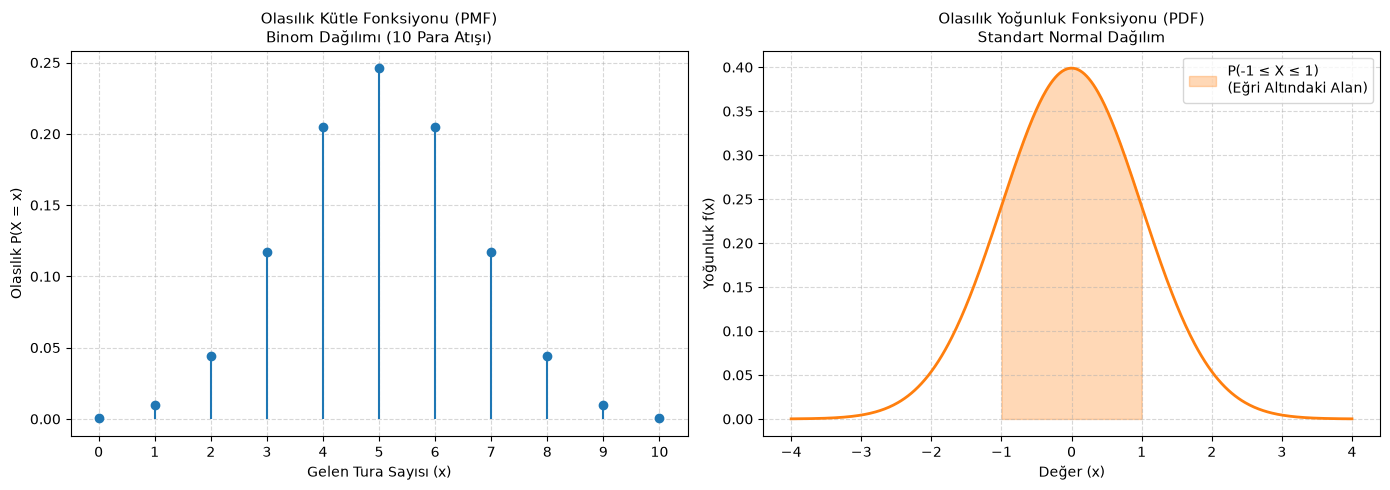

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Grafiklerin yan yana düzgün görünmesi için pencere boyutu ayarlıyoruz
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- 1. Olasılık Kütle Fonksiyonu (PMF) - Binom Dağılımı ---
# Örnek: Adil bir madeni parayı 10 kez attığımızda gelen tura sayısı
n, p = 10, 0.5
x_pmf = np.arange(0, n + 1)
y_pmf = stats.binom.pmf(x_pmf, n, p)

# PMF ayrık (kesikli) olduğu için sütun çizgileri (stem plot) kullanıyoruz
ax1.stem(x_pmf, y_pmf, basefmt=" ", linefmt="C0-", markerfmt="C0o")
ax1.set_title("Olasılık Kütle Fonksiyonu (PMF)\nBinom Dağılımı (10 Para Atışı)", fontsize=11)
ax1.set_xlabel("Gelen Tura Sayısı (x)")
ax1.set_ylabel("Olasılık P(X = x)")
ax1.set_xticks(x_pmf)
ax1.grid(True, linestyle="--", alpha=0.5)

# --- 2. Olasılık Yoğunluk Fonksiyonu (PDF) - Normal Dağılım ---
# Örnek: Ortalama=0, Standart Sapma=1 olan Standart Normal Dağılım
mu, sigma = 0, 1
x_pdf = np.linspace(-4, 4, 500)
y_pdf = stats.norm.pdf(x_pdf, mu, sigma)

# PDF sürekli olduğu için düz bir çizgi (line plot) kullanıyoruz
ax2.plot(x_pdf, y_pdf, 'C1-', linewidth=2)

# PDF'de olasılık alandır: -1 ile 1 arasındaki bölgeyi boyayalım
x_shade = np.linspace(-1, 1, 100)
y_shade = stats.norm.pdf(x_shade, mu, sigma)
ax2.fill_between(x_shade, y_shade, color='C1', alpha=0.3, label="P(-1 ≤ X ≤ 1)\n(Eğri Altındaki Alan)")

ax2.set_title("Olasılık Yoğunluk Fonksiyonu (PDF)\nStandart Normal Dağılım", fontsize=11)
ax2.set_xlabel("Değer (x)")
ax2.set_ylabel("Yoğunluk f(x)")
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.5)

# Grafikleri ekranda gösterelim.
plt.tight_layout()
plt.show()

### Sonuç
Sol grafikte 10 para atışından 0-10 arası tura gelme olasılıklarının binom dağılımını çizdik sağ grafikte ise sürekli değişkenlerde tek noktanın olasılığı 0 olduğu için noktalar arasındaki olasılığı integral yardımıyla alan alarak hesaplıyoruz.